In [13]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [14]:
%%R
library(dplyr)
library(ggplot2)

data(mtcars)
str(mtcars)
summary(mtcars)

'data.frame':	32 obs. of  11 variables:
 $ mpg : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...
      mpg             cyl             disp             hp       
 Min.   :10.40   Min.   :4.000   Min.   : 71.1   Min.   : 52.0  
 1st Qu.:15.43   1st Qu.:4.000   1st Qu.:120.8   1st Qu.: 96.5  
 Median :19.20   Median :6.000   Median :196.3   Median :123.0  
 Mean   :20.09   Mean   :6.188   Mean   :230.7   Mean   :146.7  
 3rd Qu.:22.80   3rd Qu.:8.000   3rd Qu.:326.0   3rd Qu.:180.0  
 Max.   :33.90   Max.   :8.000   Max.   :472.0   Max.   :335.0  
      drat

In [15]:
%%R
# Step 2: Variable filtering

cars_subset_base <- mtcars[, c('mpg', 'cyl', 'hp', 'wt')]

cars_subset_dplyr <- select(
  mtcars, mpg, cyl, hp, wt, gear
)

cars_drop <- select(
  mtcars, -qsec, -vs
)

In [16]:
%%R
# Step 3: Row filtering

high_mpg_base <- mtcars[mtcars$mpg > 20, ]

high_mpg_subset <- subset(
  mtcars,
  mpg > 20 & cyl == 4
)

high_mpg_dplyr <- filter(
  mtcars,
  mpg > 20,
  hp < 100
)

In [17]:
%%R
# Step 4: Handling missing data

data(airquality)

sum(is.na(airquality))

air_clean <- na.omit(airquality)

air_clean2 <- airquality[
  complete.cases(airquality),
]

`geom_smooth()` using formula = 'y ~ x'


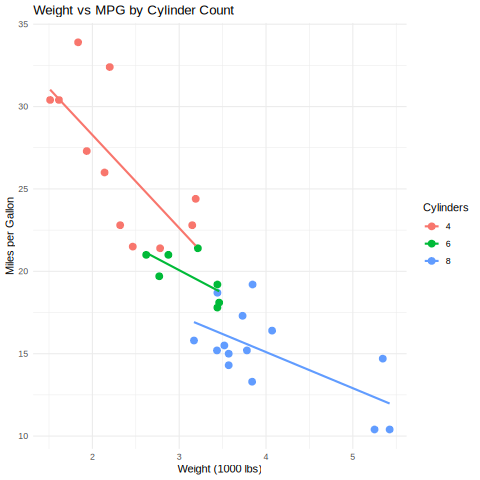

In [18]:
%%R
# Step 5: Plotting

hist(
  mtcars$mpg,
  col = 'skyblue',
  main = 'Histogram of MPG',
  xlab = 'Miles per Gallon'
)

boxplot(
  mpg ~ cyl,
  data = mtcars,
  col = 'orange',
  main = 'MPG by Number of Cylinders',
  xlab = 'Cylinders',
  ylab = 'MPG'
)

plot(
  mtcars$wt,
  mtcars$mpg,
  pch = 19,
  col = 'darkgreen',
  main = 'Weight vs MPG',
  xlab = 'Weight (1000 lbs)',
  ylab = 'MPG'
)

barplot(
  table(mtcars$cyl),
  col = 'purple',
  main = 'Count of Cars by Cylinder',
  xlab = 'Cylinders',
  ylab = 'Frequency'
)

# ggplot2 visualization

ggplot(
  mtcars,
  aes(x = wt, y = mpg, color = factor(cyl))
) +
  geom_point(size = 3) +
  geom_smooth(
    method = 'lm',
    se = FALSE
  ) +
  labs(
    title = 'Weight vs MPG by Cylinder Count',
    x = 'Weight (1000 lbs)',
    y = 'Miles per Gallon',
    color = 'Cylinders'
  ) +
  theme_minimal()